<a href="https://colab.research.google.com/github/jinyhan1/coffee-project-data/blob/main/I310_TriData_CoffeeShop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**What Makes a Coffee Shop Highly Rated? A Human-Centered Analysis of Yelp Reviews in Austin**

Method

- Data preprocessing: Removed duplicates and cleaned text data
- Rating distribution: Examined how reviews are distributed across ratings
- Sentiment by rating group: Compared sentiment across good, neutral, and bad reviews
- Attribute sentiment: Analyzed sentiment for key attributes such as coffee, service, and price
- Mean / std table: Measured average sentiment and variability across attributes
- t-test: Tested whether sentiment differences between high-rated and low-rated reviews are significant
- K-means clustering: Grouped reviews into 3 clusters based on sentiment features to identify patterns in user experience



Data loaded and cleaned.
                  coffee_shop_name  \
0  The Factory - Cafe With a Soul    
1  The Factory - Cafe With a Soul    
2  The Factory - Cafe With a Soul    
3  The Factory - Cafe With a Soul    
4  The Factory - Cafe With a Soul    

                                         review_text             rating  \
0   11/25/2016 1 check-in Love love loved the vib...   5.0 star rating    
1   12/2/2016 Listed in Date Night: Austin, vibe ...   4.0 star rating    
2   11/30/2016 1 check-in Listed in food seating ...   4.0 star rating    
3   11/25/2016 Very cool vibe! Good drinks Nice s...   2.0 star rating    
4   12/3/2016 1 check-in They are location within...   4.0 star rating    

   num_rating cat_rating  bool_HIGH  overall_sent  vibe_sent  tea_sent  \
0         5.0       HIGH        1.0           4.0        3.0       0.0   
1         4.0       HIGH        1.0           3.0        3.0       0.0   
2         4.0       HIGH        1.0           2.0        2.0       0.0   

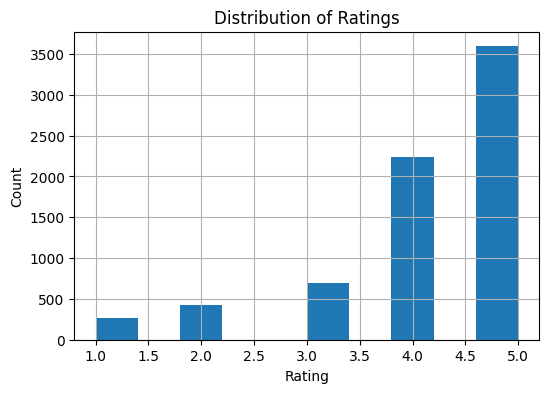

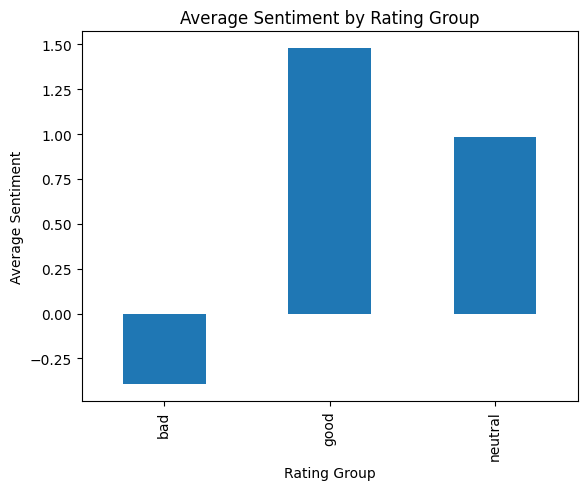

Average overall sentiment by rating group:
rating_group
bad       -0.393632
good       1.478563
neutral    0.982277
Name: overall_sent, dtype: float64



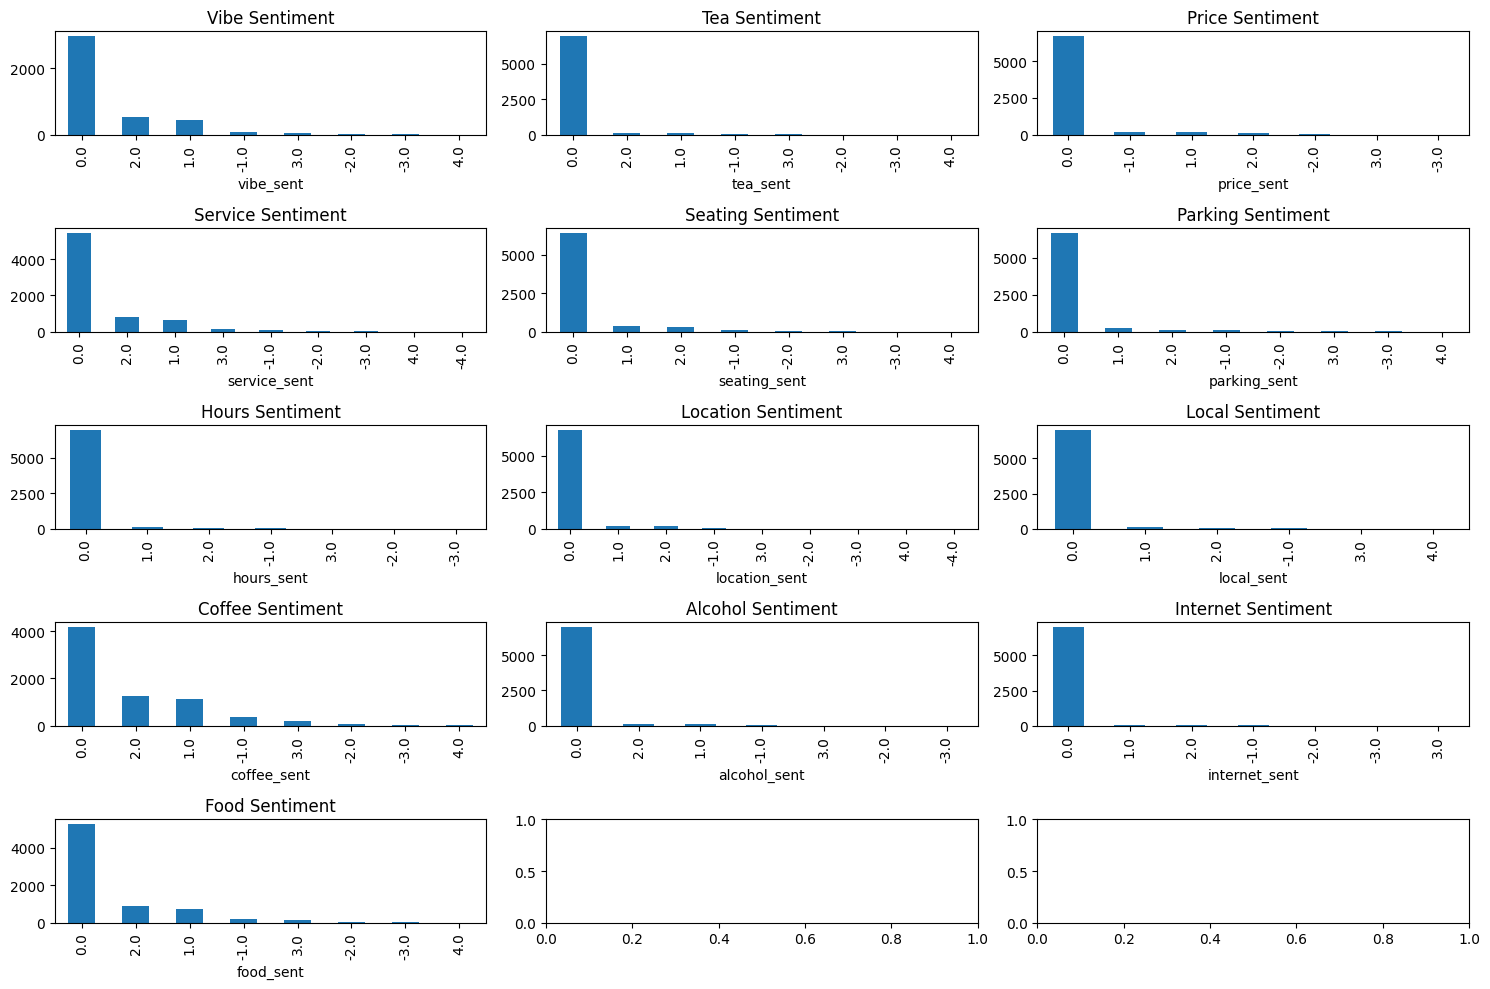

Mean and standard deviation table:
                   mean  std_deviation
num_rating     4.173202       1.062846
bool_HIGH      0.807676       0.394153
overall_sent   1.097547       1.179282
vibe_sent      0.370100       0.835968
tea_sent       0.046280       0.330990
service_sent   0.326729       0.828535
seating_sent   0.122489       0.516593
price_sent     0.020091       0.373396
parking_sent   0.048088       0.435486
location_sent  0.075655       0.398635
alcohol_sent   0.041291       0.294465
coffee_sent    0.512749       0.990238
food_sent      0.355183       0.845408
hours_sent     0.031042       0.274347
internet_sent  0.025634       0.273116
local_sent     0.037412       0.277555

T-test: High-rated vs Low-rated overall sentiment
t-statistic = 44.14964794370972
p-value = 0.0


In [ ]:
## Data Preprocessing
import pandas as pd
import re
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# Load data
url_reviews = "https://raw.githubusercontent.com/jinyhan1/coffee-project-data/main/raw_yelp_review_data.csv"
url_sent = "https://raw.githubusercontent.com/jinyhan1/coffee-project-data/main/sentiments_by_shop.csv"
url_combined = "https://raw.githubusercontent.com/jinyhan1/coffee-project-data/main/ratings_and_sentiments.csv"

reviews_df = pd.read_csv(url_reviews, encoding='latin1')
sent_df = pd.read_csv(url_sent, encoding='latin1')
ratings_df = pd.read_csv(url_combined, encoding='latin1')

# Clean combined data
ratings_df = ratings_df.drop_duplicates()
ratings_df = ratings_df.replace('#VALUE!', pd.NA)

sent_cols = [col for col in ratings_df.columns if 'sent' in col]
for col in sent_cols:
    ratings_df[col] = pd.to_numeric(ratings_df[col], errors='coerce')

ratings_df['num_rating'] = pd.to_numeric(ratings_df['num_rating'], errors='coerce')
ratings_df = ratings_df.dropna(subset=['num_rating'])

# Rating categories
def categorize_rating(x):
    if x >= 4.5:
        return "good"
    elif x >= 3.0:
        return "neutral"
    else:
        return "bad"

ratings_df['rating_group'] = ratings_df['num_rating'].apply(categorize_rating)

# Basic text cleaning
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

if 'text' in reviews_df.columns:
    reviews_df['clean_text'] = reviews_df['text'].apply(clean_text)

print("Data loaded and cleaned.")
print(ratings_df.head())
print()
print(ratings_df['rating_group'].value_counts())
print()


## 1. Distribution of Ratings
plt.figure(figsize=(6,4))
ratings_df['num_rating'].hist()
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


## 2. Average Sentiment by Rating Group
ratings_df.groupby('rating_group')['overall_sent'].mean().plot(kind='bar')
plt.title("Average Sentiment by Rating Group")
plt.xlabel("Rating Group")
plt.ylabel("Average Sentiment")
plt.show()

print("Average overall sentiment by rating group:")
print(ratings_df.groupby('rating_group')['overall_sent'].mean())
print()


## 3. Sentiment Distribution by Attribute
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 10))
fig.subplots_adjust(hspace=1, wspace=1)

ratings_df['vibe_sent'].value_counts().plot(kind = 'bar',ax=axes[0,0], title = 'Vibe Sentiment')
ratings_df['tea_sent'].value_counts().plot(kind = 'bar',ax=axes[0,1], title = 'Tea Sentiment')
ratings_df['service_sent'].value_counts().plot(kind = 'bar',ax=axes[1,0], title = 'Service Sentiment')
ratings_df['seating_sent'].value_counts().plot(kind = 'bar',ax=axes[1,1], title = 'Seating Sentiment')
ratings_df['price_sent'].value_counts().plot(kind = 'bar',ax=axes[0,2], title = 'Price Sentiment')
ratings_df['parking_sent'].value_counts().plot(kind = 'bar',ax=axes[1,2], title = 'Parking Sentiment')
ratings_df['location_sent'].value_counts().plot(kind = 'bar',ax=axes[2,1], title = 'Location Sentiment')
ratings_df['alcohol_sent'].value_counts().plot(kind = 'bar',ax=axes[3,1], title = 'Alcohol Sentiment')
ratings_df['coffee_sent'].value_counts().plot(kind = 'bar',ax=axes[3,0], title = 'Coffee Sentiment')
ratings_df['food_sent'].value_counts().plot(kind = 'bar',ax=axes[4,0], title = 'Food Sentiment')
ratings_df['hours_sent'].value_counts().plot(kind = 'bar',ax=axes[2,0], title = 'Hours Sentiment')
ratings_df['internet_sent'].value_counts().plot(kind = 'bar',ax=axes[3,2], title = 'Internet Sentiment')
ratings_df['local_sent'].value_counts().plot(kind = 'bar',ax=axes[2,2], title = 'Local Sentiment')

plt.tight_layout()
plt.show()


## 4. Mean and Standard Deviation Table
num_cols = ratings_df.select_dtypes(include='number').columns

compare_df = pd.concat(
    [ratings_df[num_cols].mean(), ratings_df[num_cols].std()],
    axis=1
)

compare_df.columns = ['mean', 'std_deviation']

print("Mean and standard deviation table:")
print(compare_df)
print()


## 5. High-rated vs Low-rated t-test
# high-rated: >= 4.5 , low-rated: <= 2.99
high_reviews = ratings_df[ratings_df['rating_group'] == 'good']['overall_sent']
low_reviews = ratings_df[ratings_df['rating_group'] == 'bad']['overall_sent']

t_stat, p_val = ttest_ind(high_reviews, low_reviews, nan_policy='omit')

print("T-test: High-rated vs Low-rated overall sentiment")
print("t-statistic =", t_stat)
print("p-value =", p_val)

In [ ]:
# K Means CLustering Setup

import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# prepare features, only using sentiment columns, drop rows with missing values
cluster_cols = ['overall_sent', 'coffee_sent', 'service_sent', 'vibe_sent',
                'food_sent', 'price_sent', 'seating_sent', 'location_sent',
                'parking_sent', 'internet_sent', 'hours_sent']
cluster_df = ratings_df[cluster_cols + ['num_rating', 'rating_group']].dropna()
X = cluster_df[cluster_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Rows of data: {len(cluster_df)}')

Rows of data: 4106


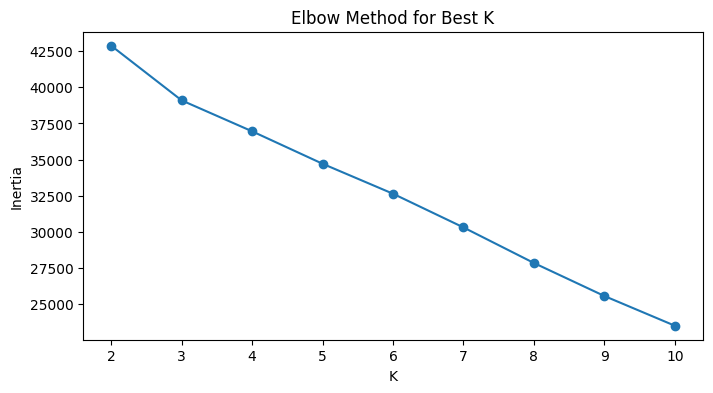

In [ ]:
# Elbow Method: Find best K for K means clustering

inertias = []
K_range = range(2,11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, marker='o')
plt.title('Elbow Method for Best K')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.xticks(list(K_range))
plt.show()

Because there isn't a noticeable elbow and instead a steady decline, there are no noticeably distinct clusters in the data. However, the sharpest drop in inertia can be seen at K = 3, therefore that will be our K value for K Means clustering.

In [ ]:
K = 3
kmeans = KMeans(n_clusters=K, random_state=42)
cluster_df = cluster_df.copy()
cluster_df['cluster'] = kmeans.fit_predict(X_scaled)

print('Reviews per cluster:')
print(cluster_df['cluster'].value_counts().sort_index())


Reviews per cluster:
cluster
0    1578
1     143
2    2385
Name: count, dtype: int64


Cluster Profile Summary:


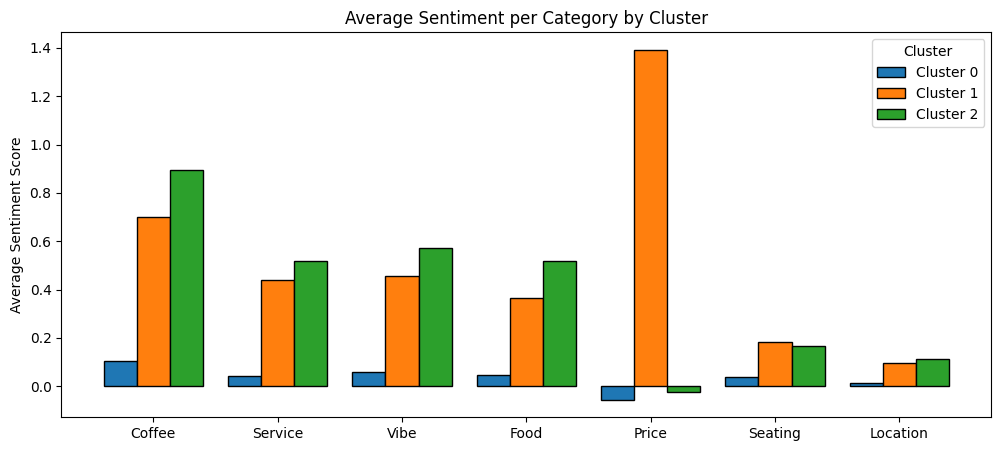

In [ ]:
# Visualize cluster profiles

profile = cluster_df.groupby('cluster').agg(
    num_reviews      = ('cluster',       'count'),
    avg_rating       = ('num_rating',    'mean'),
    avg_overall      = ('overall_sent',  'mean'),
    avg_coffee       = ('coffee_sent',   'mean'),
    avg_service      = ('service_sent',  'mean'),
    avg_vibe         = ('vibe_sent',     'mean'),
    avg_food         = ('food_sent',     'mean'),
    avg_price        = ('price_sent',    'mean'),
    avg_seating      = ('seating_sent',  'mean'),
    avg_location     = ('location_sent', 'mean'),
).round(3)

print('Cluster Profile Summary:')

sentiment_means = profile[['avg_coffee', 'avg_service', 'avg_vibe',
                            'avg_food', 'avg_price', 'avg_seating', 'avg_location']]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(sentiment_means.columns))
width = 0.8 / K
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
          '#9467bd', '#8c564b', '#e377c2']

for i in range(K):
    ax.bar(x + i * width, sentiment_means.iloc[i],
           width, label=f'Cluster {i}', color=colors[i],
           edgecolor='black',)

ax.set_title('Average Sentiment per Category by Cluster')
ax.set_xticks(x + width * (K - 1) / 2)
ax.set_xticklabels(['Coffee', 'Service', 'Vibe', 'Food',
                    'Price', 'Seating', 'Location'])
ax.set_ylabel('Average Sentiment Score')
ax.legend(title='Cluster')
plt.show()

Explanation of clusters:

Cluster 0 (blue): This is the group of customers that didn't leave any extraordinary reviews, most likely just leaving a rating and nothing else. It was also the largest group with 1578 reviews left, showing how many people don't think too much of a rating when they come to a coffee shop.

Cluster 1 (orange): This group is very price conscious, as it can be seen from the graph that there is a massive spike in Price sentiment from this group. This shows that these people specifically valued price more than any other component in a coffee shop, irregardless of it being good or bad.

Cluster 2 (green): This group shows consistently positive sentiment across coffee, service, vibe, and food, indicating overall satisfaction and a well-rounded experience.

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, cluster_df['cluster'])
print(f'Silhouette Score: {score}')

Silhouette Score: 0.10930504103750785
